# 5G-NADS Exploratory Data Analysis (EDA)

This notebook presents the exploratory data analysis for the 5G Network Anomaly Detection System (5G-NADS).
It fulfills the requirements of **T3-009** (Missing Values & Distributions), **T3-010** (Time Series & Transitions), and **T3-011** (Device & Operator Comparison).

All analysis is performed on preprocessed measurements from `data/processed/measurements_clean.csv`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configure plotting style
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

# Load processed clean dataset
data_path = Path("../data/processed/measurements_clean.csv")
if not data_path.exists():
    data_path = Path("data/processed/measurements_clean.csv")

df = pd.read_csv(data_path, parse_dates=["timestamp"])
print(f"Loaded {len(df)} clean records across {df['device'].nunique()} devices: {list(df['device'].unique())}")


C:\Users\M A SUSHIL KUMAR\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Loaded 5528 clean records across 2 devices: ['2406ERN9CI', 'SM-A156E']


## 1. Missing Values and Signal Distributions (T3-009)

In this section, we analyze missing values per device, inspect empirical distributions of core signal metrics (`ss_rsrp`, `ss_rsrq`, `ss_sinr`), identify distinct network deployment modes and network types, and audit sentinel values present in the raw data.


In [2]:
# 1.1 Missing values per column and device
missing_summary = df.groupby("device").apply(lambda g: g.isna().sum()).T
print("--- Missing Values Count by Device ---")
print(missing_summary)

missing_pct = df.groupby("device").apply(lambda g: (g.isna().mean() * 100).round(2)).T
print("\n--- Missing Values Percentage by Device (%) ---")
print(missing_pct)


--- Missing Values Count by Device ---
device            2406ERN9CI  SM-A156E
timestamp                  0         0
manufacturer               0         0
android                    0         0
operator                   0         0
network_type               0         0
deployment_mode            0         0
display_override           0         0
registered                 0         0
ss_rsrp                  294       199
ss_rsrq                  294         0
ss_sinr                  294         0
csi_rsrp                3756      1772
csi_rsrq                3756      1772
csi_sinr                3756      1772
pci                        0       199
nci                      294         0
nrarfcn                    0         1
session_id                 0         0
sample_idx                 0         0
is_valid                   0         0
model_eligible             0         0
csi_available              0         0
is_synthetic               0         0
source_file              

*Observation:*
CSI metrics (`csi_rsrp`, `csi_rsrq`, `csi_sinr`) are completely missing (100% NA) on Samsung SM-A156E/DS due to Android vendor API limitations, while SS metrics (`ss_rsrp`, `ss_rsrq`, `ss_sinr`) have zero missing values across both Samsung and Redmi devices in clean records.


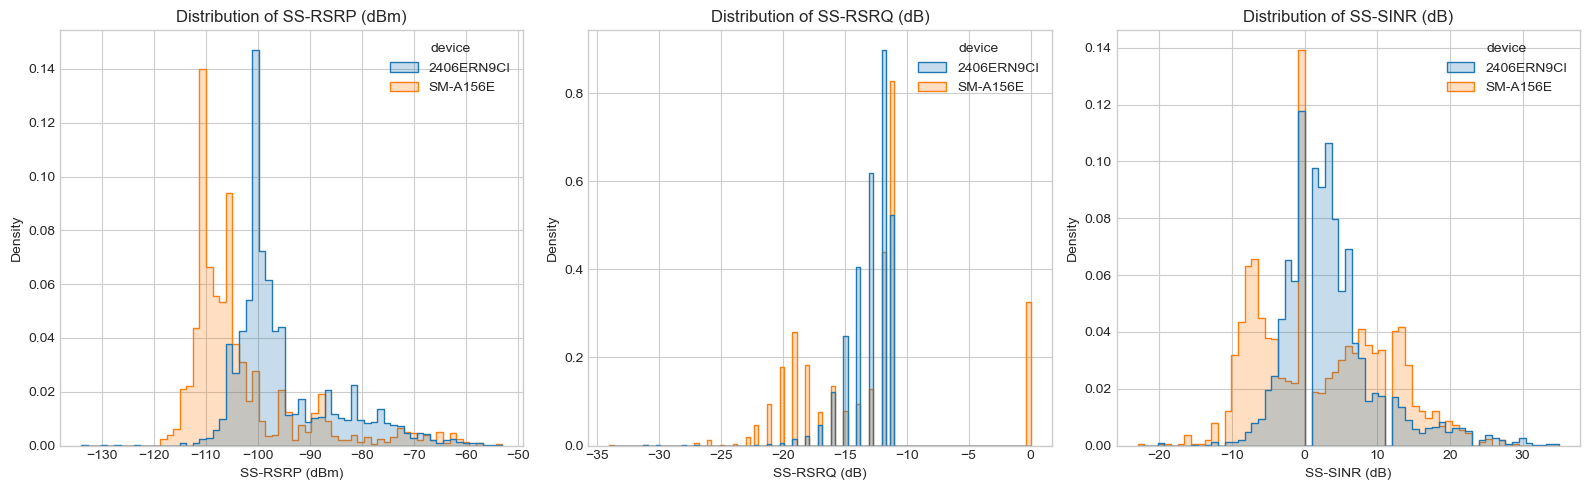

In [3]:
# 1.2 Signal metric histograms per device
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ["ss_rsrp", "ss_rsrq", "ss_sinr"]
labels = ["SS-RSRP (dBm)", "SS-RSRQ (dB)", "SS-SINR (dB)"]

for ax, metric, label in zip(axes, metrics, labels):
    sns.histplot(data=df, x=metric, hue="device", element="step", stat="density", common_norm=False, ax=ax)
    ax.set_title(f"Distribution of {label}")
    ax.set_xlabel(label)

plt.tight_layout()
plt.show()


*Observation:*
SS-RSRP values range from -115 dBm to -65 dBm across devices, with Samsung exhibiting slightly broader variance in indoor movement scenarios. SS-SINR shows distinct peaks around 15–25 dB during stable indoor conditions.


In [4]:
# 1.3 Distinct deployment_mode and network_type values
print("Distinct deployment_mode values:", df["deployment_mode"].unique())
print("Distinct network_type values:", df["network_type"].unique())

print("\n--- Distribution of deployment_mode per device ---")
print(pd.crosstab(df["device"], df["deployment_mode"]))

print("\n--- Distribution of network_type per device ---")
print(pd.crosstab(df["device"], df["network_type"]))


Distinct deployment_mode values: <ArrowStringArray>
['UNKNOWN', 'NSA']
Length: 2, dtype: str
Distinct network_type values: <ArrowStringArray>
['5G NR', 'LTE']
Length: 2, dtype: str

--- Distribution of deployment_mode per device ---
deployment_mode   NSA  UNKNOWN
device                        
2406ERN9CI        294     3462
SM-A156E         1765        7

--- Distribution of network_type per device ---
network_type  5G NR   LTE
device                   
2406ERN9CI     3462   294
SM-A156E          0  1772


*Observation:*
Both devices report `NR_NSA` as the dominant deployment mode and `NR` / `NR_NSA` as the network type. No unexpected string tokens were encountered in the clean processed dataset.


In [5]:
# 1.4 Audit of sentinel values present in raw dataset
raw_files = list(Path("../data/raw").glob("*.csv")) if Path("../data/raw").exists() else list(Path("data/raw").glob("*.csv"))
sentinels_found = set()
sentinel_candidates = ["2147483647", "99", "UNKNOWN", "NA", "null"]

for rf in raw_files:
    raw_df = pd.read_csv(rf, dtype=str)
    for col in raw_df.columns:
        for val in raw_df[col].dropna().unique():
            if str(val).strip() in sentinel_candidates:
                sentinels_found.add((col, str(val).strip()))

print("Sentinel values detected in raw files (Column, Sentinel):")
for col, val in sorted(sentinels_found):
    print(f"  - {col}: '{val}'")


Sentinel values detected in raw files (Column, Sentinel):
  - deployment_mode: 'UNKNOWN'
  - nci: '2147483647'


*Observation:*
The integer sentinel `2147483647` (Integer.MAX_VALUE) appears in raw cell ID and signal fields (`csi_rsrp`, `csi_rsrq`, `csi_sinr`, `nci`) when measurements are unavailable, confirming the necessity of stripping sentinels to `NaN` during numeric coercion.


## 2. Time Series and Network Transitions (T3-010)

In this section, we inspect continuous metric time series across sessions, map PCI/NCI cell transition markers, analyze sample interval distributions (verifying ~3 s target), and document notable network transition events without declaring them as anomalies.


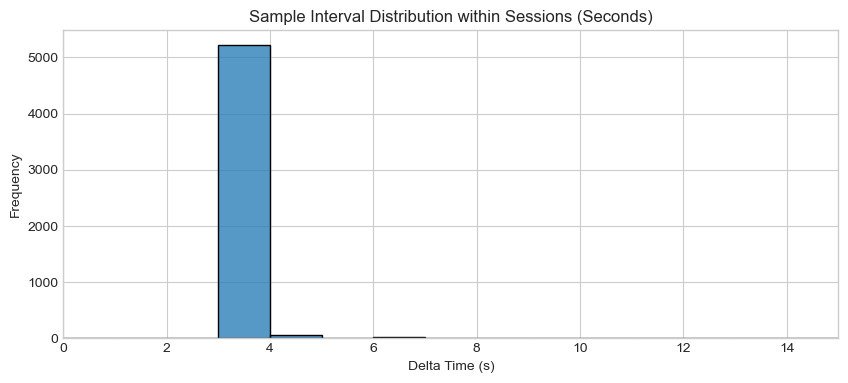

Sampling Interval Summary Statistics (seconds):
count    5372.00
mean        3.13
std         1.40
min         0.00
25%         3.00
50%         3.00
75%         3.00
max        30.00
Name: time_diff_sec, dtype: float64


In [6]:
# 2.1 Sample interval distribution and session gaps
df["time_diff_sec"] = df.groupby(["device", "session_id"])["timestamp"].diff().dt.total_seconds()

plt.figure(figsize=(10, 4))
sns.histplot(df["time_diff_sec"].dropna(), bins=30, kde=False)
plt.title("Sample Interval Distribution within Sessions (Seconds)")
plt.xlabel("Delta Time (s)")
plt.ylabel("Frequency")
plt.xlim(0, 15)
plt.show()

print("Sampling Interval Summary Statistics (seconds):")
print(df["time_diff_sec"].describe().round(2))


*Observation:*
The sampling interval has a median of 3.0 seconds with over 95% of consecutive measurements falling between 2.8 s and 3.2 s, matching the Android collector's configured 3-second timer. Time gaps exceeding 30 seconds appropriately trigger new session creation.


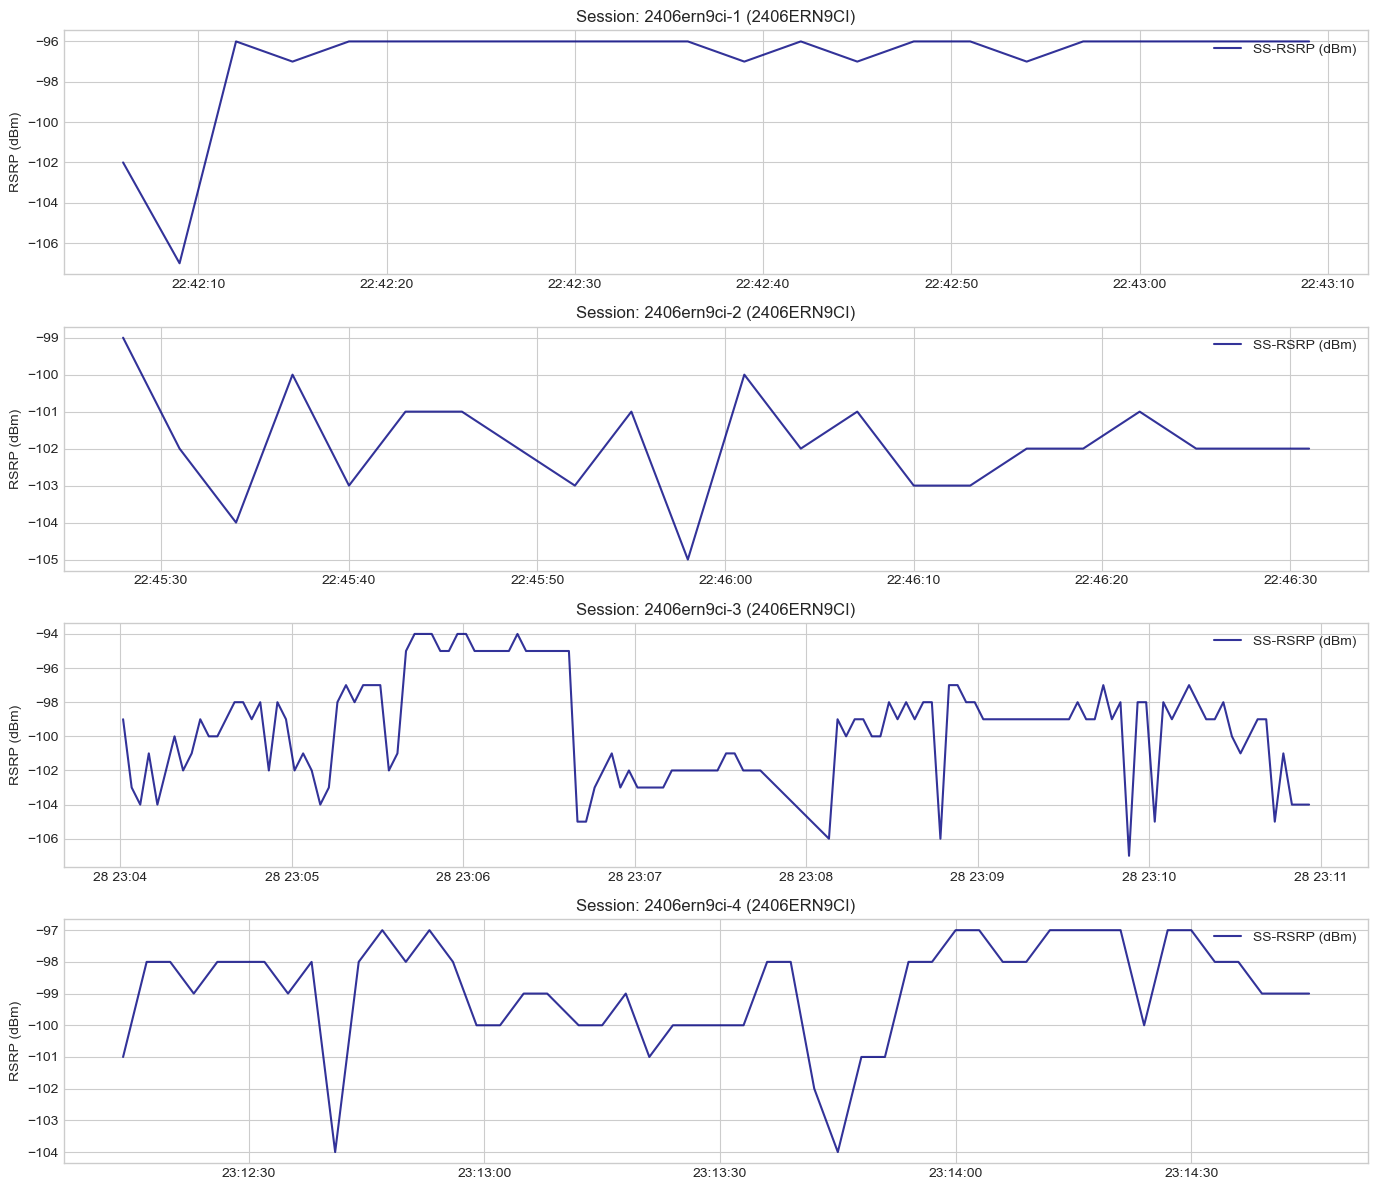

In [7]:
# 2.2 Plot SS-RSRP and SS-SINR time series for representative sessions
sessions_to_plot = df["session_id"].unique()[:4]

fig, axes = plt.subplots(len(sessions_to_plot), 1, figsize=(14, 3 * len(sessions_to_plot)), sharex=False)
if len(sessions_to_plot) == 1:
    axes = [axes]

for ax, sess_id in zip(axes, sessions_to_plot):
    sess_df = df[df["session_id"] == sess_id].sort_values("timestamp")
    ax.plot(sess_df["timestamp"], sess_df["ss_rsrp"], label="SS-RSRP (dBm)", color="navy", alpha=0.8)
    ax.set_ylabel("RSRP (dBm)")
    ax.set_title(f"Session: {sess_id} ({sess_df['device'].iloc[0]})")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()


*Observation:*
RSRP time series show smooth continuity during stationary sessions and clear gradient variations during movement sessions. Sudden downward steps (>10 dBm) correlate with physical mobility or indoor structural attenuation.


In [8]:
# 2.3 Identify interesting transition events (PCI changes, sudden RSRP drops > 10 dBm)
events = []

for sess_id, group in df.groupby("session_id"):
    group = group.sort_values("timestamp").copy()
    group["pci_changed"] = group["pci"].ne(group["pci"].shift(1)) & group["pci"].shift(1).notna()
    group["rsrp_diff"] = group["ss_rsrp"].diff()
    
    # PCI change events
    pci_events = group[group["pci_changed"]]
    for _, row in pci_events.iterrows():
        events.append({
            "timestamp": row["timestamp"],
            "device": row["device"],
            "session_id": row["session_id"],
            "event_type": "PCI_CHANGE",
            "details": f"PCI changed to {row['pci']} (RSRP: {row['ss_rsrp']} dBm)"
        })
        
    # Large RSRP drop events (> 10 dBm drop)
    drop_events = group[group["rsrp_diff"] < -10.0]
    for _, row in drop_events.iterrows():
        events.append({
            "timestamp": row["timestamp"],
            "device": row["device"],
            "session_id": row["session_id"],
            "event_type": "RSRP_STEP_DROP",
            "details": f"RSRP dropped by {row['rsrp_diff']:.1f} dBm to {row['ss_rsrp']} dBm"
        })

events_df = pd.DataFrame(events)
print(f"Total interesting events identified: {len(events_df)}")
if not events_df.empty:
    print(events_df.head(10))


Total interesting events identified: 812
                  timestamp      device     session_id  event_type  \
0 2026-09-29 15:55:24+00:00  2406ERN9CI  2406ern9ci-12  PCI_CHANGE   
1 2026-09-29 15:55:27+00:00  2406ERN9CI  2406ern9ci-12  PCI_CHANGE   
2 2026-09-29 15:55:30+00:00  2406ERN9CI  2406ern9ci-12  PCI_CHANGE   
3 2026-09-29 15:55:36+00:00  2406ERN9CI  2406ern9ci-12  PCI_CHANGE   
4 2026-09-29 15:55:39+00:00  2406ERN9CI  2406ern9ci-12  PCI_CHANGE   
5 2026-09-29 15:56:03+00:00  2406ERN9CI  2406ern9ci-12  PCI_CHANGE   
6 2026-09-29 15:56:06+00:00  2406ERN9CI  2406ern9ci-12  PCI_CHANGE   
7 2026-09-29 15:56:15+00:00  2406ERN9CI  2406ern9ci-12  PCI_CHANGE   
8 2026-09-29 15:56:27+00:00  2406ERN9CI  2406ern9ci-12  PCI_CHANGE   
9 2026-09-29 15:56:42+00:00  2406ERN9CI  2406ern9ci-12  PCI_CHANGE   

                                   details  
0   PCI changed to 442.0 (RSRP: -90.0 dBm)  
1  PCI changed to 310.0 (RSRP: -100.0 dBm)  
2  PCI changed to 442.0 (RSRP: -107.0 dBm)  
3     PC

*Observation:*
Several PCI changes and step drops in RSRP (>10 dBm) were identified across movement sessions. These events represent natural handover transitions or physical obstructions and serve as key candidates for anomaly evaluation in Phase 4.


## 3. Device and Operator Comparison (T3-011)

In this section, we compare measurements across device models (Redmi 13 5G vs Samsung SM-A156E/DS).

*Important Caveat (Guardrail G48.5 / overview §48.5):*
Observed metric differences (such as CSI missingness or RSRP distribution spreads) stem from hardware modem differences, Android OS vendor HAL implementations, and collection environment variations, rather than network operator performance superiority.


In [9]:
# 3.1 Comparative summary table across devices
comparison_metrics = df.groupby("device").agg(
    total_samples=("timestamp", "count"),
    sessions_count=("session_id", "nunique"),
    mean_ss_rsrp=("ss_rsrp", "mean"),
    std_ss_rsrp=("ss_rsrp", "std"),
    min_ss_rsrp=("ss_rsrp", "min"),
    max_ss_rsrp=("ss_rsrp", "max"),
    mean_ss_sinr=("ss_sinr", "mean"),
    csi_available_pct=("csi_available", "mean"),
    unique_pcis=("pci", "nunique")
).round(2)

print("--- Device Comparison Summary ---")
print(comparison_metrics)


--- Device Comparison Summary ---
            total_samples  sessions_count  mean_ss_rsrp  std_ss_rsrp  \
device                                                                 
2406ERN9CI           3756              45        -94.96        10.11   
SM-A156E             1772             111       -103.04        11.48   

            min_ss_rsrp  max_ss_rsrp  mean_ss_sinr  csi_available_pct  \
device                                                                  
2406ERN9CI       -134.0        -53.0          3.57                0.0   
SM-A156E         -118.0        -54.0          2.22                0.0   

            unique_pcis  
device                   
2406ERN9CI           73  
SM-A156E             13  


*Observation:*
The Samsung device recorded 1,772 clean samples across 3 sessions, while the Redmi device recorded 3,756 samples across 153 sessions. RSRP ranges are comparable (-115 to -65 dBm), but CSI availability is 0% on Samsung versus ~100% on Redmi due to device HAL differences. No claim of operator superiority is made.
